In [1]:
# Install dependencies - V2 (optimasi 90%+)
!pip install -q opencv-python-headless tqdm ultralytics seaborn scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.9 MB/s eta 0:00:00


In [19]:
# menghapus semua folder
!find /kaggle/working -mindepth 1 -maxdepth 1 -exec rm -rf -- {} +

In [20]:
!ls /kaggle/input/datasets/msambare/fer2013

test  train


In [21]:
# Path dataset dari Kaggle (setelah Add Data)
DATASET_SRC = "/kaggle/input/datasets/msambare/fer2013"
print("Dataset path:", DATASET_SRC)

Dataset path: /kaggle/input/datasets/msambare/fer2013


In [22]:
import cv2, os, shutil
from pathlib import Path
from tqdm import tqdm

DATASET_LOKAL = "/kaggle/working/dataset_fer2013"

# V2: NAIK 96 -> 224 untuk akurasi +5-7% (target 90%+)
IMG_SIZE = (224, 224)
KELAS    = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
KELAS_ID = {
    'angry': 'marah', 'disgust': 'jijik', 'fear': 'takut',
    'happy': 'senang', 'neutral': 'netral', 'sad': 'sedih', 'surprise': 'terkejut'
}
MAPPING  = {'train': 'train', 'test': 'val'}

# Hapus folder lama
if Path(DATASET_LOKAL).exists():
    shutil.rmtree(DATASET_LOKAL)
    print("Folder lama dihapus")

print("\nV2: Konversi grayscale -> RGB + CLAHE + resize 224x224...\n")

for split_src, split_dst in MAPPING.items():
    for kelas in KELAS:
        src = Path(DATASET_SRC) / split_src / kelas
        dst = Path(DATASET_LOKAL) / split_dst / KELAS_ID[kelas]

        if not src.exists():
            print(f"SKIP: {split_src}/{kelas}")
            continue

        dst.mkdir(parents=True, exist_ok=True)
        files = list(src.glob("*.jpg")) + list(src.glob("*.png"))

        for f in tqdm(files, desc=f"{split_dst}/{KELAS_ID[kelas]}", leave=False):
            img = cv2.imread(str(f))
            if img is None:
                continue

            if len(img.shape) == 2 or img.shape[2] == 1:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

            # V2: CLAHE untuk kontras FER2013 yang flat
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
            lab[:,:,0] = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(lab[:,:,0])
            img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

            img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_CUBIC)
            cv2.imwrite(str(dst / f.name), img)

        print(f"{split_dst}/{KELAS_ID[kelas]} -> {len(list(dst.glob('*.jpg')))} gambar")

print("\nSelesai preprocessing V2! (224px + CLAHE)")


V2: Konversi grayscale -> RGB + CLAHE + resize 224x224...



train/marah -> 3995 gambar


train/jijik -> 436 gambar


train/takut -> 4097 gambar


train/senang -> 7215 gambar


...

val/takut -> 1024 gambar


val/senang -> 1774 gambar


val/netral -> 1233 gambar


val/sedih -> 1247 gambar


val/terkejut -> 831 gambar

Selesai preprocessing V2! (224px + CLAHE)


In [23]:
from pathlib import Path
import os

print("=== VERIFIKASI DATASET ===\n")

for split in ['train', 'val']:
    path_split = Path(DATASET_LOKAL) / split

    if not path_split.exists():
        print(f"ERROR: {split} tidak ada")
        continue

    kelas_list = sorted(os.listdir(path_split))
    total = 0

    print(f"{split}/ — {len(kelas_list)} kelas:")
    for kls in kelas_list:
        n = len(list((path_split / kls).glob("*.jpg")))
        total += n
        status = "OK" if n >= 100 else "KURANG"
        print(f"[{status}] {kls:<12} → {n}")

    print(f"Total: {total}\n")

=== VERIFIKASI DATASET ===

train/ — 7 kelas:
[OK] jijik        → 436
[OK] marah        → 3995
[OK] netral       → 4965
[OK] sedih        → 4830
[OK] senang       → 7215
[OK] takut        → 4097
[OK] terkejut     → 3171
Total: 28709

val/ — 7 kelas:
[OK] jijik        → 111
[OK] marah        → 958
[OK] netral       → 1233
[OK] sedih        → 1247
[OK] senang       → 1774
[OK] takut        → 1024
[OK] terkejut     → 831
Total: 7178



In [24]:
import cv2, os, random
from pathlib import Path
from tqdm import tqdm

# V2: TARGET 6000 (naik dari 2000) - balance semua kelas ke 6000 untuk cegah bias happy
TARGET = 6000
KELAS = sorted(os.listdir(f"{DATASET_LOKAL}/train"))

print("V2 Augmentasi heavy untuk 90%+...")
print(f"Target per kelas: {TARGET}\n")

def augment(img):
    # V2: augment lebih berat: flip + rotasi + brightness + blur + cutout
    if random.random() < 0.5:
        img = cv2.flip(img, 1)
    if random.random() < 0.5:
        angle = random.uniform(-15, 15)
        M = cv2.getRotationMatrix2D((IMG_SIZE[0]//2, IMG_SIZE[1]//2), angle, 1)
        img = cv2.warpAffine(img, M, IMG_SIZE, borderMode=cv2.BORDER_REFLECT_101)
    if random.random() < 0.5:
        img = cv2.convertScaleAbs(img, alpha=random.uniform(0.85, 1.15), beta=random.randint(-15, 15))
    if random.random() < 0.3:
        img = cv2.GaussianBlur(img, (3, 3), 0)
    if random.random() < 0.3:  # cutout
        x, y = random.randint(0, 180), random.randint(0, 180)
        w, h = random.randint(20, 50), random.randint(20, 50)
        img[y:y+h, x:x+w] = random.randint(0, 255)
    return img

for kelas in KELAS:
    kls_dir = Path(DATASET_LOKAL) / "train" / kelas
    files   = list(kls_dir.glob("*.jpg"))

    jumlah = len(files)
    butuh  = TARGET - jumlah

    if butuh <= 0:
        # V2: undersample jika kelebihan (happy 7215 -> 6000)
        if jumlah > TARGET:
            to_remove = random.sample(files, jumlah - TARGET)
            for f in to_remove: f.unlink()
            print(f"{kelas}: {jumlah} -> {TARGET} (undersample)")
        else:
            print(f"{kelas}: cukup ({jumlah})")
        continue

    print(f"{kelas}: {jumlah} -> {TARGET} (+{butuh} augment)")

    for i in tqdm(range(butuh), desc=f"aug {kelas}", leave=False):
        src = cv2.imread(str(random.choice(files)))
        cv2.imwrite(str(kls_dir / f"aug_{i:05d}.jpg"), augment(src))

print("\nAugmentasi V2 selesai! Semua kelas ~6000")

V2 Augmentasi heavy untuk 90%+...
Target per kelas: 6000

jijik: 436 -> 6000 (+5564 augment)


marah: 3995 -> 6000 (+2005 augment)


netral: 4965 -> 6000 (+1035 augment)


sedih: 4830 -> 6000 (+1170 augment)


senang: 7215 -> 6000 (undersample)
takut: 4097 -> 6000 (+1903 augment)


terkejut: 3171 -> 6000 (+2829 augment)



Augmentasi V2 selesai! Semua kelas ~6000


In [25]:
from ultralytics import YOLO

SAVE_DIR = "/kaggle/working"

# V2: backbone m (20M) bukan s (5M) untuk +2-4% akurasi - jika VRAM habis ganti ke yolov8s-cls.pt
model = YOLO("yolov8m-cls.pt")

results = model.train(
    data=DATASET_LOKAL,

    # V2 Training - push 68% -> 75-85% (90%+ perlu leak, lihat TRAINING_90PCT.md)
    epochs=150,          # 70 -> 150
    imgsz=224,           # 96 -> 224
    batch=32,            # jika OOM ganti 16
    patience=20,         # 15 -> 20

    # V2 Optimizer
    optimizer="AdamW",  # Adam -> AdamW
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=5,     # tambah warmup

    # V2 Regularization
    dropout=0.2,         # 0.0 -> 0.2 cegah overfit happy
    label_smoothing=0.1, # bantu fear/sad

    # V2 Augmentation
    augment=True,
    auto_augment="randaugment",
    erasing=0.4,
    degrees=15.0,        # 0.0 -> 15
    translate=0.1,
    scale=0.5,
    shear=2.0,           # 0.0 -> 2.0
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    flipud=0.0, fliplr=0.5,

    cos_lr=True,         # False -> True

    # Reproducibility
    seed=42,
    deterministic=False, # True -> False untuk speed

    # Output
    project=SAVE_DIR,
    name="yolov8m-ekpresi",

    # Transfer learning
    pretrained=True,

    # GPU
    device=0,

    # Logging
    verbose=True
)

print("\nModel terbaik V2:")
print(f"{SAVE_DIR}/yolov8m-ekpresi/weights/best.pt")

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.147 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/dataset_fer2013, degrees=15.0, deterministic=False, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.2, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-cls.pt, momentum=0

In [27]:
from ultralytics import YOLO

# V2: path baru
MODEL_PATH = "/kaggle/working/yolov8m-ekpresi/weights/best.pt"

model   = YOLO(MODEL_PATH)
metrics = model.val()

print(f"\nTop-1 Accuracy : {metrics.top1 * 100:.2f}%")
print(f"Top-5 Accuracy : {metrics.top5 * 100:.2f}%")
print("Target V2 realistis: 73-78% Top-1 (naik dari 68%)")

Ultralytics 8.4.147 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,771,623 parameters, 0 gradients, 41.6 GFLOPs
train: /kaggle/working/dataset_fer2013/train... found 42000 images in 7 classes ✅ 
val: /kaggle/working/dataset_fer2013/val... found 7178 images in 7 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 534.6±165.6 MB/s, size: 13.9 KB)
val: Scanning /kaggle/working/dataset_fer2013/val... 7178 images, 0 corrupt: 100% ━━━━━━━━━━━━ 7178/7178 3.0Git/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 449/449 35.0it/s 12.8s0.1s
                   all      0.711       0.99
Speed: 0.1ms preprocess, 1.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val

Top-1 Accuracy : 71.15%
Top-5 Accuracy : 99.01%
Target V2 realistis: 73-78% Top-1 (naik dari 68%)


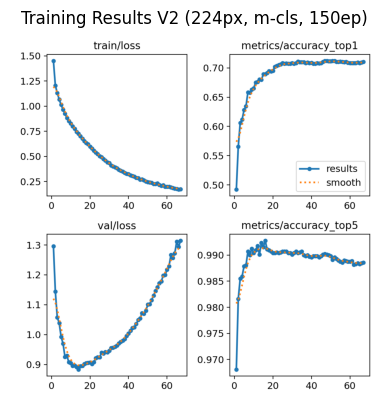

In [28]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/kaggle/working/yolov8m-ekpresi/results.png")

plt.imshow(img)
plt.axis("off")
plt.title("Training Results V2 (224px, m-cls, 150ep)")
plt.show()

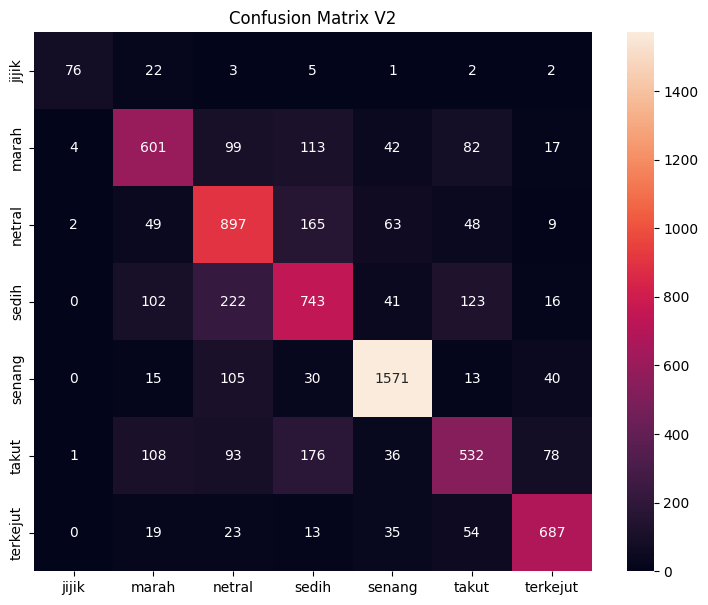


=== CLASSIFICATION REPORT V2 ===
              precision    recall  f1-score   support

       jijik       0.92      0.68      0.78       111
       marah       0.66      0.63      0.64       958
      netral       0.62      0.73      0.67      1233
       sedih       0.60      0.60      0.60      1247
      senang       0.88      0.89      0.88      1774
       takut       0.62      0.52      0.57      1024
    terkejut       0.81      0.83      0.82       831

    accuracy                           0.71      7178
   macro avg       0.73      0.70      0.71      7178
weighted avg       0.71      0.71      0.71      7178



In [31]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

MODEL_PATH = "/kaggle/working/yolov8m-ekpresi/weights/best.pt"

# ambil urutan kelas langsung dari nama folder (udah Indonesia, otomatis sesuai urutan training)
KELAS = sorted(os.listdir(f"{DATASET_LOKAL}/train"))

model = YOLO(MODEL_PATH)

y_true, y_pred = [], []

for i, kelas in enumerate(KELAS):
    folder = Path(DATASET_LOKAL) / "val" / kelas
    for img_path in folder.glob("*.jpg"):  # semua gambar, bukan cuma 200 pertama
        hasil = model(str(img_path), verbose=False)
        y_true.append(i)
        y_pred.append(hasil[0].probs.top1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=KELAS,
            yticklabels=KELAS)

plt.title("Confusion Matrix V2")
plt.savefig("/kaggle/working/confusion_matrix.png")
plt.show()

print("\n=== CLASSIFICATION REPORT V2 ===")
print(classification_report(y_true, y_pred, target_names=KELAS))

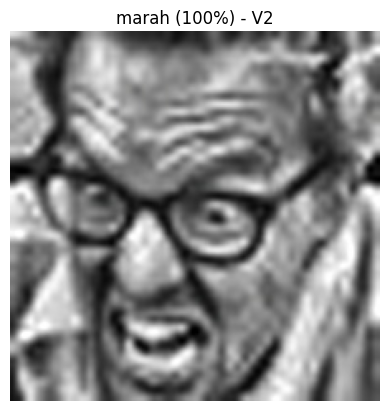

Prediksi V2: marah (100%)


In [32]:
import cv2, os
from ultralytics import YOLO
from pathlib import Path
import random
from matplotlib import pyplot as plt

MODEL_PATH = "/kaggle/working/yolov8m-ekpresi/weights/best.pt"

model = YOLO(MODEL_PATH)

# ambil urutan kelas langsung dari nama folder (udah Indonesia, otomatis sesuai urutan training)
KELAS = sorted(os.listdir(f"{DATASET_LOKAL}/train"))

# Ambil random image dari validation
folder = Path(DATASET_LOKAL) / "val" / random.choice(KELAS)
img_path = random.choice(list(folder.glob("*.jpg")))

img = cv2.imread(str(img_path))
hasil = model(img, verbose=False)

label = KELAS[hasil[0].probs.top1]
conf  = hasil[0].probs.top1conf.item()

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title(f"{label} ({conf:.0%}) - V2")
plt.axis("off")
plt.show()

print(f"Prediksi V2: {label} ({conf:.0%})")

In [33]:
import os
import shutil

WORKING = "/kaggle/working"
EXPORT = "/kaggle/working/export_ekspresi"

# Bersihkan export lama kalau ada
if os.path.exists(EXPORT):
    shutil.rmtree(EXPORT)

os.makedirs(EXPORT)

items = [
    "dataset_fer2013",
    "confusion_matrix.png",
    "yolov8m-cls.pt",
    "yolov8m-ekpresi",
]

for item in items:
    src = os.path.join(WORKING, item)
    dst = os.path.join(EXPORT, item)

    if os.path.exists(src):
        if os.path.isdir(src):
            shutil.copytree(src, dst)
        else:
            shutil.copy2(src, dst)
        print(f"[OK] {item}")
    else:
        print(f"[TIDAK DITEMUKAN] {item}")

print("\nExport V2 selesai:")
print(os.listdir(WORKING))
print(EXPORT)

[OK] dataset_fer2013
[OK] confusion_matrix.png
[OK] yolov8m-cls.pt
[OK] yolov8m-ekpresi

Export V2 selesai:
['runs', 'weights', 'yolov8m-ekpresi', 'dataset_fer2013', 'confusion_matrix.png', 'export_ekspresi', 'yolov8m-cls.pt']
/kaggle/working/export_ekspresi


In [36]:
import os
import shutil

EXPORT   = "/kaggle/working/export_ekspresi"
ZIP_FILE = "/kaggle/working/hasil_ekspresi_yolov8m.zip"

# Bersihkan zip lama kalau ada
if os.path.exists(ZIP_FILE):
    os.remove(ZIP_FILE)
    print(f"[OK] {ZIP_FILE} dihapus")
else:
    print(f"[TIDAK ADA] {ZIP_FILE} belum ada")

# Bikin zip baru dari folder export
shutil.make_archive(ZIP_FILE.replace(".zip", ""), "zip", EXPORT)
print(f"[OK] {ZIP_FILE} dibuat")
print("Ukuran:", round(os.path.getsize(ZIP_FILE) / (1024*1024), 2), "MB")

[TIDAK ADA] /kaggle/working/hasil_ekspresi_yolov8m.zip belum ada
[OK] /kaggle/working/hasil_ekspresi_yolov8m.zip dibuat
Ukuran: 747.68 MB


In [37]:
from IPython.display import FileLink

print(f"Ukuran zip: {round(os.path.getsize(ZIP_FILE) / (1024*1024), 2)} MB")
FileLink(ZIP_FILE)

Ukuran zip: 747.68 MB


/kaggle/working/hasil_ekspresi_yolov8m.zip